In [15]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook


# ============================================================
# CONFIG
# ============================================================
path = "raw/gdp-ind-table2.xlsx"   # <-- ajusta si tu ruta es distinta


# ============================================================
# 1) LEER EXCEL CON MERGES (rellenando valores)
# ============================================================
def sheet_matrix_fill_merged(ws):
    merged_value = {}
    for r in ws.merged_cells.ranges:
        top_left = ws.cell(r.min_row, r.min_col).value
        for rr in range(r.min_row, r.max_row + 1):
            for cc in range(r.min_col, r.max_col + 1):
                merged_value[(rr, cc)] = top_left

    mat = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_value:
                v = merged_value[(rr, cc)]
            row.append(v)
        mat.append(row)
    return mat


wb = load_workbook(path, data_only=True)
ws = wb.active
mat = sheet_matrix_fill_merged(ws)

# versión "string" para buscar patrones
mat_str = [[("" if v is None else str(v)).strip() for v in row] for row in mat]


# ============================================================
# 2) ENCONTRAR LA FILA DE TRIMESTRES (la que tiene muchos Q1..Q4)
# ============================================================
def count_quarters(row):
    return sum(1 for x in row if re.search(r"\bQ[1-4]\b", x))

quarter_row = None
best = 0
for i in range(min(80, len(mat_str))):
    c = count_quarters(mat_str[i])
    if c > best:
        best = c
        quarter_row = i

if quarter_row is None or best < 6:
    raise ValueError("No pude encontrar la fila de trimestres (Q1..Q4).")

# ============================================================
# 3) ARMAR MAPA DE COLUMNAS TRIMESTRALES: col -> 'YYYYQ#'
#    (buscando el año hacia arriba en la misma columna)
# ============================================================
quarter_cols = []
quarter_names = []

for j, qtxt in enumerate(mat_str[quarter_row]):
    m = re.search(r"\bQ([1-4])\b", qtxt)
    if not m:
        continue
    qnum = m.group(1)

    # buscar año arriba (hasta 10 renglones hacia arriba)
    year = None
    for k in range(1, 11):
        r_up = quarter_row - k
        if r_up < 0:
            break
        cand = mat_str[r_up][j]
        if re.fullmatch(r"\d{4}", cand):
            year = cand
            break

    if year is None:
        # a veces el año está 1-2 columnas a la izquierda por merges visuales
        for shift in (1, 2, 3):
            jj = j - shift
            if jj < 0:
                continue
            for k in range(1, 11):
                r_up = quarter_row - k
                if r_up < 0:
                    break
                cand = mat_str[r_up][jj]
                if re.fullmatch(r"\d{4}", cand):
                    year = cand
                    break
            if year is not None:
                break

    if year is None:
        continue  # si no hallamos año, no usamos esa columna

    quarter_cols.append(j)
    quarter_names.append(f"{year}Q{qnum}")

if len(quarter_cols) == 0:
    raise ValueError("Detecté Q1..Q4 pero no pude asignarles año (YYYY).")


# ============================================================
# 4) ENCONTRAR DONDE EMPIEZAN LOS DATOS (renglón con '1' en col A)
# ============================================================
data_start = None
for i in range(quarter_row + 1, min(quarter_row + 60, len(mat_str))):
    if re.fullmatch(r"\d+", mat_str[i][0]):  # col A = Line
        data_start = i
        break

if data_start is None:
    raise ValueError("No encontré el inicio de datos (líneas numéricas en col A).")


# ============================================================
# 5) CONSTRUIR df_wide: line, component, 2021Q4, 2022Q1, ...
# ============================================================
records = []
for i in range(data_start, len(mat_str)):
    line_txt = mat_str[i][0]
    comp_txt = mat_str[i][1] if len(mat_str[i]) > 1 else ""

    if not re.fullmatch(r"\d+", line_txt):
        # cuando se acaba la tabla, BEA suele dejar bloques vacíos o texto
        # cortamos si pasan muchos renglones sin líneas
        continue

    line = int(line_txt)
    component = comp_txt.strip()
    if component == "":
        continue

    row = {"line": line, "component": component}
    for j, name in zip(quarter_cols, quarter_names):
        v = mat[i][j]
        row[name] = v
    records.append(row)

df_wide = pd.DataFrame(records)

# numéricos
for c in quarter_names:
    df_wide[c] = pd.to_numeric(df_wide[c], errors="coerce")

print("✅ df_wide shape:", df_wide.shape)
print("✅ columnas trimestrales ejemplo:", quarter_names[:8])
display(df_wide.head())


# ============================================================
# 6) ARMAR DF PARA LA FIGURA (a)
# ============================================================
lines_needed = {
    2:  "Consumo privado",
    39: "Inversión residencial",
    28: "Inversión no residencial",
    40: "Inventarios",
    43: "Exportaciones netas",
    50: "Gasto público",
}

df_contrib = df_wide[df_wide["line"].isin(lines_needed)].copy()
df_contrib["component_es"] = df_contrib["line"].map(lines_needed)

df_total = df_wide[df_wide["line"].eq(1)].copy()
if df_total.empty:
    raise ValueError("No encontré línea 1 (Gross domestic product) para el Total.")

# long
long = df_contrib.melt(
    id_vars=["component_es"],
    value_vars=quarter_names,
    var_name="period",
    value_name="value"
)

total_long = df_total.melt(
    id_vars=["component"],
    value_vars=quarter_names,
    var_name="period",
    value_name="gdp_growth"
)

def pkey(p):
    return (int(p[:4]), int(p[-1]))

periods_sorted = sorted(long["period"].unique(), key=pkey)
long["period"] = pd.Categorical(long["period"], categories=periods_sorted, ordered=True)
total_long["period"] = pd.Categorical(total_long["period"], categories=periods_sorted, ordered=True)

pivot = long.pivot_table(index="period", columns="component_es", values="value", aggfunc="first").sort_index()
gdp = total_long.groupby("period")["gdp_growth"].first().sort_index()

# recorte tipo tu imagen (2021–2024)
keep = [p for p in pivot.index.astype(str) if (2021,1) <= pkey(p) <= (2025,3)]
pivot = pivot.loc[keep]
gdp = gdp.loc[keep]


print("✅ pivot shape:", pivot.shape)
print("✅ NaNs por columna:\n", pivot.isna().sum())




✅ df_wide shape: (60, 18)
✅ columnas trimestrales ejemplo: ['2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3']


,line,component,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3
0,1,Gross domestic product,7.00,-1.00,0.60,2.90,2.80,2.90,2.50,4.70,3.40,0.80,3.60,3.30,1.90,-0.60,3.80,4.40
1,2,Personal consumption expenditures,2.63,0.22,2.19,1.27,0.53,2.99,1.02,2.08,2.04,1.17,2.61,2.66,2.61,0.42,1.68,2.34
2,3,Goods,0.81,-0.48,-0.11,-0.58,-0.52,1.55,0.09,0.95,0.47,-0.29,1.14,1.27,1.43,0.04,0.47,0.64
3,4,Durable goods,0.50,-0.01,-0.11,-0.12,-0.38,1.29,0.01,0.48,0.02,-0.07,0.56,0.61,0.92,-0.26,0.17,0.12
4,5,Motor vehicles and parts,0.05,0.09,-0.12,-0.08,-0.14,0.78,-0.24,-0.04,-0.24,-0.18,0.17,0.29,0.42,-0.31,0.23,-0.17


✅ pivot shape: (16, 6)
✅ NaNs por columna:
 component_es
Consumo privado             0
Exportaciones netas         0
Gasto público               0
Inventarios                 0
Inversión no residencial    0
Inversión residencial       0
dtype: int64


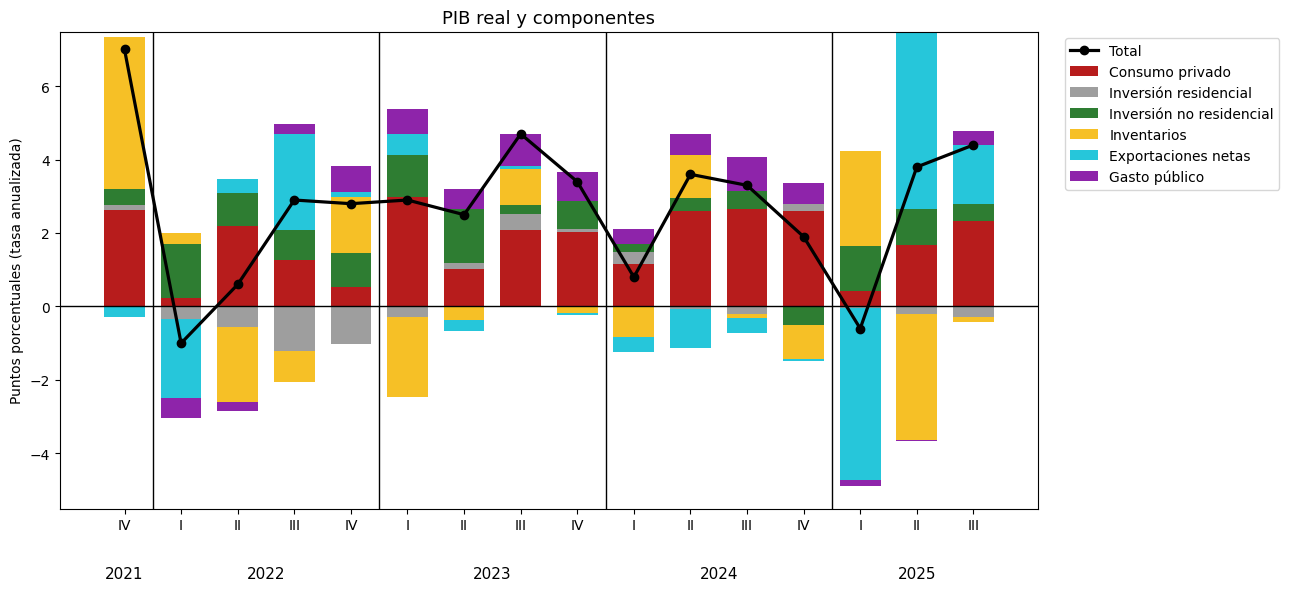

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# ORDEN Y COLORES (como tu figura)
# ---------------------------------
order = [
    "Consumo privado",
    "Inversión residencial",
    "Inversión no residencial",
    "Inventarios",
    "Exportaciones netas",
    "Gasto público",
]

colors = {
    "Consumo privado": "#b71c1c",        # rojo oscuro
    "Inversión residencial": "#9e9e9e",  # gris
    "Inversión no residencial": "#2e7d32",# verde
    "Inventarios": "#f6c026",            # amarillo
    "Exportaciones netas": "#26c6da",    # azul turquesa
    "Gasto público": "#8e24aa",          # morado
}

roman = {1: "I", 2: "II", 3: "III", 4: "IV"}

# =========================
# EJE X TIPO FIGURA
# =========================
periods = [str(p) for p in pivot.index]
years = [int(p[:4]) for p in periods]
quarters = [int(p[-1]) for p in periods]

x = np.arange(len(periods))
xlabels = [roman[q] for q in quarters]

unique_years = sorted(set(years))
year_centers = {}
for y in unique_years:
    idx = [i for i, yy in enumerate(years) if yy == y]
    year_centers[y] = (idx[0] + idx[-1]) / 2

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(13, 6))

pos_bottom = np.zeros(len(periods))
neg_bottom = np.zeros(len(periods))

for comp in order:
    if comp not in pivot.columns:
        continue

    vals = pivot[comp].astype(float).values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    ax.bar(
        x, pos,
        bottom=pos_bottom,
        color=colors[comp],
        width=0.72,
        label=comp
    )

    ax.bar(
        x, neg,
        bottom=neg_bottom,
        color=colors[comp],
        width=0.72,
        label="_nolegend_"
    )

    pos_bottom += pos
    neg_bottom += neg

# Línea total
ax.plot(
    x,
    gdp.astype(float).values,
    color="black",
    marker="o",
    linewidth=2.3,
    label="Total",
    zorder=10
)

ax.axhline(0, color="black", linewidth=1)

# =========================
# FORMATO DE EJE
# =========================
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=10)

# Separadores por año
for y in unique_years[:-1]:
    last = max(i for i, yy in enumerate(years) if yy == y)
    ax.axvline(last + 0.5, color="black", linewidth=1)

# Año centrado abajo
ymin, ymax = ax.get_ylim()
yr_y = ymin - 0.12*(ymax - ymin)

for y, cx in year_centers.items():
    ax.text(cx, yr_y, str(y), ha="center", va="top", fontsize=11)

ax.set_ylabel("Puntos porcentuales (tasa anualizada)")
ax.set_xlabel("")
ax.set_title("PIB real y componentes", fontsize=13)

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()


In [12]:
import pandas as pd

# ---------
# 1. Cargar archivos
# ---------

path = "raw/"

indpro = pd.read_csv(path + "INDPRO.csv", parse_dates=["observation_date"])
ipman  = pd.read_csv(path + "IPMAN.csv", parse_dates=["observation_date"])
ipmine = pd.read_csv(path + "IPMINE.csv", parse_dates=["observation_date"])
iputil = pd.read_csv(path + "IPUTIL.csv", parse_dates=["observation_date"])

# ---------
# 2. Renombrar columnas
# ---------

indpro.columns = ["date", "total"]
ipman.columns  = ["date", "manufacturas"]
ipmine.columns = ["date", "mineria"]
iputil.columns = ["date", "utilities"]

# ---------
# 3. Unir en un solo dataframe
# ---------

df = indpro.merge(ipman, on="date") \
           .merge(ipmine, on="date") \
           .merge(iputil, on="date")

# ---------
# 4. Filtrar desde 2019
# ---------

df = df[df["date"] >= "2019-01-01"].copy()

# ---------
# 5. Re-escalar a enero 2019 = 100
# ---------

base = df[df["date"] == "2019-01-01"]

for col in ["total", "manufacturas", "mineria", "utilities"]:
    base_val = base[col].values[0]
    df[col] = 100 * df[col] / base_val

# ---------
# 6. Promedio móvil 3 meses
# ---------

for col in ["total", "manufacturas", "mineria", "utilities"]:
    df[col] = df[col].rolling(3).mean()

# ---------
# 7. Tabla final
# ---------

tabla_final = df.dropna().reset_index(drop=True)

tabla_final.head()


,date,total,manufacturas,mineria,utilities
0,2019-03-01,99.648170,99.530421,99.151260,101.109261
1,2019-04-01,99.284508,99.043066,99.476969,100.728691
2,2019-05-01,99.141023,98.749278,100.309303,100.463872
3,2019-06-01,98.999762,98.658475,101.282175,98.503160
4,2019-07-01,98.892350,98.545797,100.940366,98.754601


In [14]:
tabla_final.to_csv(
    "raw/industrial_production_panel_b.csv",
    index=False
)


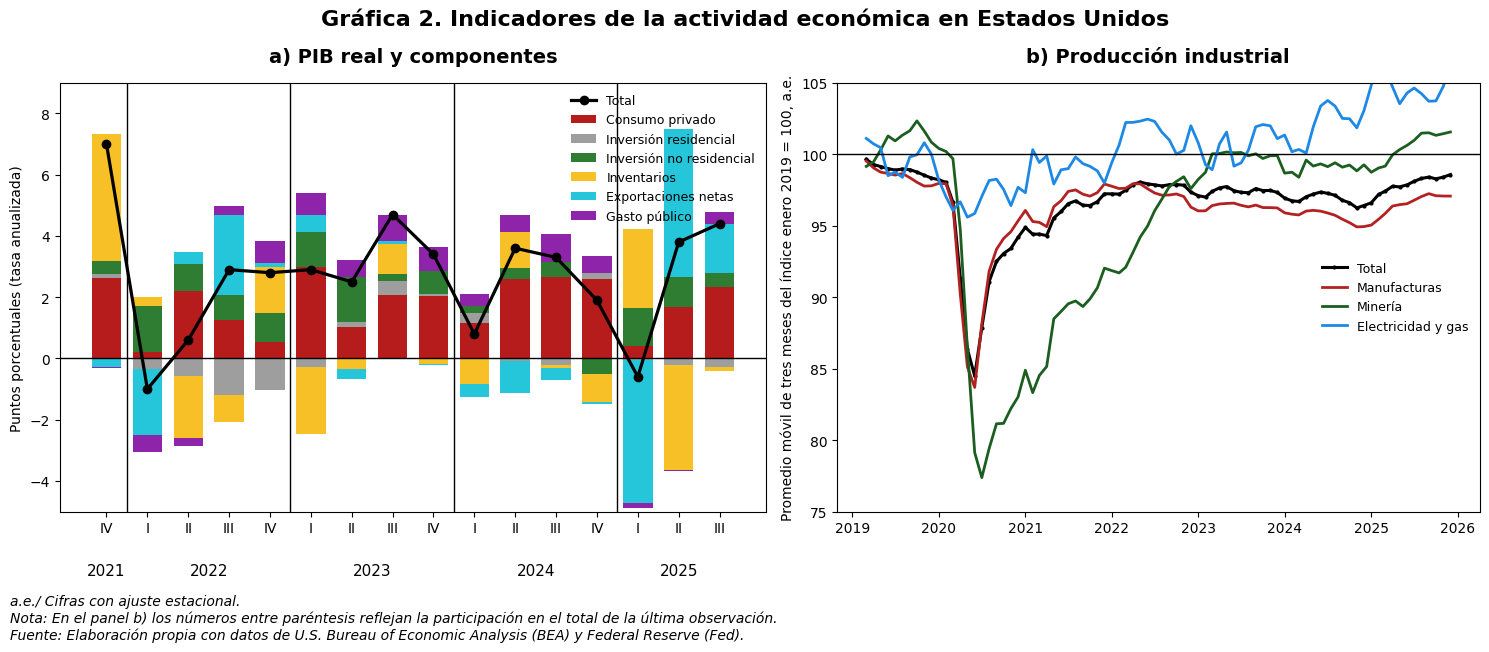

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# ============================================================
# CONFIG (ajusta si tu ruta es distinta)
# ============================================================
path_excel = "raw/gdp-ind-table2.xlsx"   # Panel (a)
path_fred  = "raw/"                     # Panel (b) CSVs: INDPRO/IPMAN/IPMINE/IPUTIL

# ============================================================
# 1) LEER EXCEL CON MERGES (rellenando valores)
# ============================================================
def sheet_matrix_fill_merged(ws):
    merged_value = {}
    for r in ws.merged_cells.ranges:
        top_left = ws.cell(r.min_row, r.min_col).value
        for rr in range(r.min_row, r.max_row + 1):
            for cc in range(r.min_col, r.max_col + 1):
                merged_value[(rr, cc)] = top_left

    mat = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_value:
                v = merged_value[(rr, cc)]
            row.append(v)
        mat.append(row)
    return mat

wb = load_workbook(path_excel, data_only=True)
ws = wb.active
mat = sheet_matrix_fill_merged(ws)
mat_str = [[("" if v is None else str(v)).strip() for v in row] for row in mat]

# ============================================================
# 2) ENCONTRAR FILA DE TRIMESTRES (Q1..Q4)
# ============================================================
def count_quarters(row):
    return sum(1 for x in row if re.search(r"\bQ[1-4]\b", x))

quarter_row, best = None, 0
for i in range(min(80, len(mat_str))):
    c = count_quarters(mat_str[i])
    if c > best:
        best, quarter_row = c, i

if quarter_row is None or best < 6:
    raise ValueError("No pude encontrar la fila de trimestres (Q1..Q4).")

# ============================================================
# 3) MAPA columnas -> 'YYYYQ#'
# ============================================================
quarter_cols, quarter_names = [], []

for j, qtxt in enumerate(mat_str[quarter_row]):
    m = re.search(r"\bQ([1-4])\b", qtxt)
    if not m:
        continue
    qnum = m.group(1)

    year = None
    for k in range(1, 11):
        r_up = quarter_row - k
        if r_up < 0:
            break
        cand = mat_str[r_up][j]
        if re.fullmatch(r"\d{4}", cand):
            year = cand
            break

    if year is None:
        for shift in (1, 2, 3):
            jj = j - shift
            if jj < 0:
                continue
            for k in range(1, 11):
                r_up = quarter_row - k
                if r_up < 0:
                    break
                cand = mat_str[r_up][jj]
                if re.fullmatch(r"\d{4}", cand):
                    year = cand
                    break
            if year is not None:
                break

    if year is None:
        continue

    quarter_cols.append(j)
    quarter_names.append(f"{year}Q{qnum}")

if len(quarter_cols) == 0:
    raise ValueError("Detecté Q1..Q4 pero no pude asignarles año (YYYY).")

# ============================================================
# 4) INICIO DE DATOS (línea numérica en col A)
# ============================================================
data_start = None
for i in range(quarter_row + 1, min(quarter_row + 60, len(mat_str))):
    if re.fullmatch(r"\d+", mat_str[i][0]):
        data_start = i
        break
if data_start is None:
    raise ValueError("No encontré el inicio de datos (líneas numéricas en col A).")

# ============================================================
# 5) df_wide
# ============================================================
records = []
for i in range(data_start, len(mat_str)):
    line_txt = mat_str[i][0]
    comp_txt = mat_str[i][1] if len(mat_str[i]) > 1 else ""
    if not re.fullmatch(r"\d+", line_txt):
        continue

    line = int(line_txt)
    component = comp_txt.strip()
    if component == "":
        continue

    row = {"line": line, "component": component}
    for j, name in zip(quarter_cols, quarter_names):
        row[name] = mat[i][j]
    records.append(row)

df_wide = pd.DataFrame(records)
for c in quarter_names:
    df_wide[c] = pd.to_numeric(df_wide[c], errors="coerce")

# ============================================================
# 6) pivot + gdp para panel (a)
# ============================================================
lines_needed = {
    2:  "Consumo privado",
    39: "Inversión residencial",
    28: "Inversión no residencial",
    40: "Inventarios",
    43: "Exportaciones netas",
    50: "Gasto público",
}

df_contrib = df_wide[df_wide["line"].isin(lines_needed)].copy()
df_contrib["component_es"] = df_contrib["line"].map(lines_needed)

df_total = df_wide[df_wide["line"].eq(1)].copy()
if df_total.empty:
    raise ValueError("No encontré línea 1 (Gross domestic product) para el Total.")

long = df_contrib.melt(
    id_vars=["component_es"],
    value_vars=quarter_names,
    var_name="period",
    value_name="value"
)

total_long = df_total.melt(
    id_vars=["component"],
    value_vars=quarter_names,
    var_name="period",
    value_name="gdp_growth"
)

def pkey(p): return (int(p[:4]), int(p[-1]))
periods_sorted = sorted(long["period"].unique(), key=pkey)

long["period"] = pd.Categorical(long["period"], categories=periods_sorted, ordered=True)
total_long["period"] = pd.Categorical(total_long["period"], categories=periods_sorted, ordered=True)

pivot = long.pivot_table(index="period", columns="component_es", values="value", aggfunc="first").sort_index()
gdp = total_long.groupby("period")["gdp_growth"].first().sort_index()

# recorte para que se parezca a tu imagen (2021–2024; ajusta si quieres)
keep = [p for p in pivot.index.astype(str) if (2021,1) <= pkey(p) <= (2025,3)]
pivot = pivot.loc[keep]
gdp = gdp.loc[keep]

# ============================================================
# 7) Panel (b): FRED CSVs -> (enero 2019=100) + MA(3)
# ============================================================
def read_fred_csv(fname, newcol):
    df = pd.read_csv(path_fred + fname, parse_dates=["observation_date"])
    series_col = [c for c in df.columns if c != "observation_date"][0]
    df = df.rename(columns={"observation_date": "date", series_col: newcol})
    df[newcol] = pd.to_numeric(df[newcol], errors="coerce")
    return df

indpro = read_fred_csv("INDPRO.csv", "total")
ipman  = read_fred_csv("IPMAN.csv", "manufacturas")
ipmine = read_fred_csv("IPMINE.csv", "mineria")
iputil = read_fred_csv("IPUTIL.csv", "utilities")

df_b = indpro.merge(ipman, on="date").merge(ipmine, on="date").merge(iputil, on="date")
df_b = df_b[df_b["date"] >= "2019-01-01"].copy()

base = df_b[df_b["date"] == pd.Timestamp("2019-01-01")]
if base.empty:
    raise ValueError("No encontré 2019-01-01 en los CSVs de FRED. Revisa que estén completos.")
for c in ["total", "manufacturas", "mineria", "utilities"]:
    df_b[c] = 100 * df_b[c] / float(base[c].iloc[0])

for c in ["total", "manufacturas", "mineria", "utilities"]:
    df_b[c] = df_b[c].rolling(3).mean()

df_b = df_b.dropna().reset_index(drop=True)

# ============================================================
# 8) PLOT FINAL (a + b): leyendas adentro, más "cuadrado"
# ============================================================

# --- formato panel (a) como tu figura ---
order = [
    "Consumo privado",
    "Inversión residencial",
    "Inversión no residencial",
    "Inventarios",
    "Exportaciones netas",
    "Gasto público",
]

colors = {
    "Consumo privado": "#b71c1c",         # rojo oscuro
    "Inversión residencial": "#9e9e9e",   # gris
    "Inversión no residencial": "#2e7d32",# verde
    "Inventarios": "#f6c026",             # amarillo
    "Exportaciones netas": "#26c6da",     # azul turquesa
    "Gasto público": "#8e24aa",           # morado
}

roman = {1: "I", 2: "II", 3: "III", 4: "IV"}

periods = [str(p) for p in pivot.index]
years = [int(p[:4]) for p in periods]
quarters = [int(p[-1]) for p in periods]

x = np.arange(len(periods))
xlabels = [roman[q] for q in quarters]

unique_years = sorted(set(years))
year_centers = {}
for y in unique_years:
    idx = [i for i, yy in enumerate(years) if yy == y]
    year_centers[y] = (idx[0] + idx[-1]) / 2

# --- figura con dos paneles ---
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

# ---------------- Panel (a)
pos_bottom = np.zeros(len(periods))
neg_bottom = np.zeros(len(periods))

for comp in order:
    if comp not in pivot.columns:
        continue

    vals = pivot[comp].astype(float).values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    ax1.bar(x, pos, bottom=pos_bottom, color=colors[comp], width=0.72, label=comp)
    ax1.bar(x, neg, bottom=neg_bottom, color=colors[comp], width=0.72, label="_nolegend_")

    pos_bottom += pos
    neg_bottom += neg

ax1.plot(
    x, gdp.astype(float).values,
    color="black", marker="o", linewidth=2.3,
    label="Total", zorder=10
)
ax1.axhline(0, color="black", linewidth=1)

# eje X romano + separadores por año + año centrado abajo
# ---- escala fija panel (a)
ax1.set_ylim(-5, 9)

ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, fontsize=10)

for y in unique_years[:-1]:
    last = max(i for i, yy in enumerate(years) if yy == y)
    ax1.axvline(last + 0.5, color="black", linewidth=1)

ymin, ymax = ax1.get_ylim()
yr_y = ymin - 0.12*(ymax - ymin)
for y, cx in year_centers.items():
    ax1.text(cx, yr_y, str(y), ha="center", va="top", fontsize=11)

ax1.set_ylabel("Puntos porcentuales (tasa anualizada)")
ax1.set_xlabel("")
ax1.set_title("a) PIB real y componentes", fontsize=14, fontweight="bold", pad=15)

# ✅ leyenda adentro (arriba, sin salir a la derecha)
ax1.legend(loc="upper right", frameon=False, fontsize=9)

# ---------------- Panel (b)
ax2.plot(df_b["date"], df_b["total"], color="black", linewidth=2.2, marker="o", markersize=2, label="Total")
ax2.plot(df_b["date"], df_b["manufacturas"], color="#b22222", linewidth=2, label="Manufacturas")
ax2.plot(df_b["date"], df_b["mineria"], color="#1b5e20", linewidth=2, label="Minería")
ax2.plot(df_b["date"], df_b["utilities"], color="#1e88e5", linewidth=2, label="Electricidad y gas")

ax2.axhline(100, color="black", linewidth=1)
ax2.set_ylim(75, 105)

ax2.set_title("b) Producción industrial", fontsize=14, fontweight="bold", pad=15)
ax2.set_ylabel("Promedio móvil de tres meses del índice enero 2019 = 100, a.e.")
ax2.set_xlabel("")

# ✅ leyenda adentro (derecha media) para que quede compacta
ax2.legend(loc="center right", frameon=False, fontsize=9)

fig.suptitle("Gráfica 2. Indicadores de la actividad económica en Estados Unidos", fontsize=16, fontweight="bold", y=0.98)
# ---- nota al pie
fig.text(
    0.01, -0.07,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel b) los números entre paréntesis reflejan la participación en el total de la última observación.\n"
    "Fuente: Elaboración propia con datos de U.S. Bureau of Economic Analysis (BEA) y Federal Reserve (Fed).",
     fontsize=10, style="italic"
)

plt.tight_layout()
plt.show()


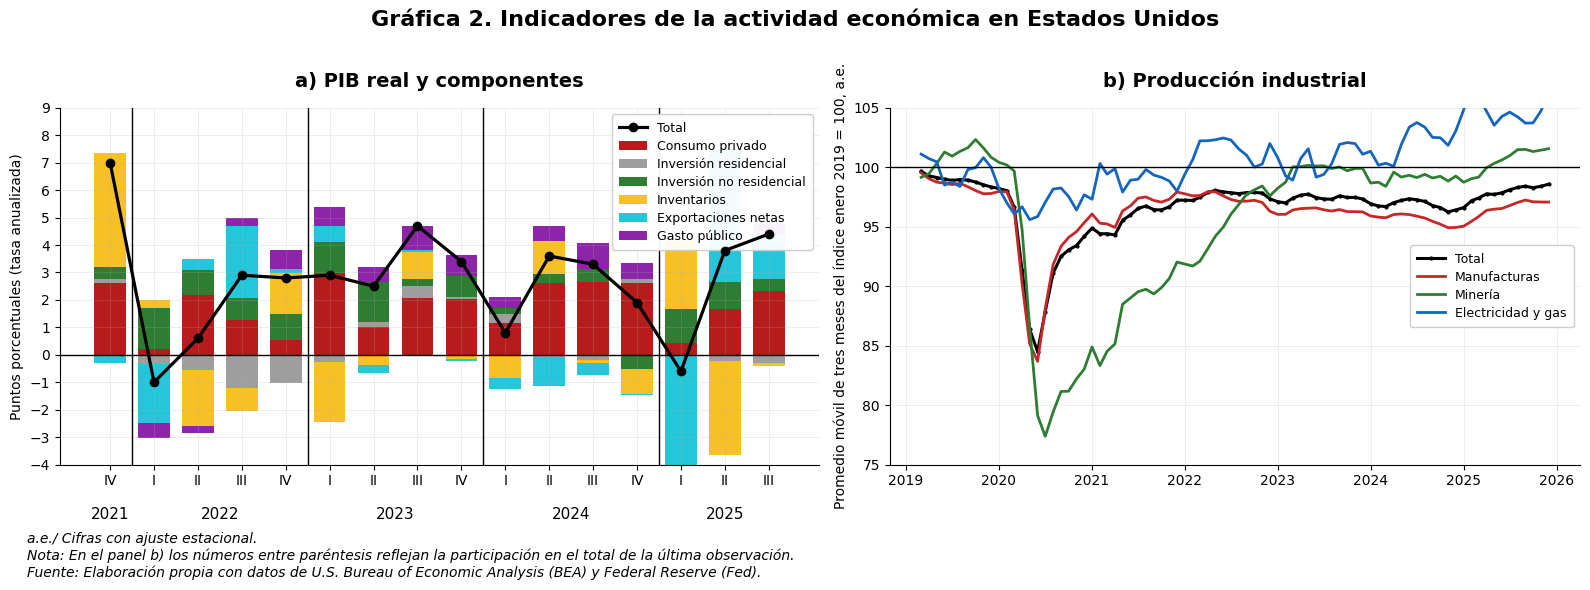

In [28]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# ============================================================
# CONFIG (ajusta si tu ruta es distinta)
# ============================================================
path_excel = "raw/gdp-ind-table2.xlsx"   # Panel (a)
path_fred  = "raw/"                     # Panel (b) CSVs: INDPRO/IPMAN/IPMINE/IPUTIL

# ============================================================
# 1) LEER EXCEL CON MERGES (rellenando valores)
# ============================================================
def sheet_matrix_fill_merged(ws):
    merged_value = {}
    for r in ws.merged_cells.ranges:
        top_left = ws.cell(r.min_row, r.min_col).value
        for rr in range(r.min_row, r.max_row + 1):
            for cc in range(r.min_col, r.max_col + 1):
                merged_value[(rr, cc)] = top_left

    mat = []
    for rr in range(1, ws.max_row + 1):
        row = []
        for cc in range(1, ws.max_column + 1):
            v = ws.cell(rr, cc).value
            if v is None and (rr, cc) in merged_value:
                v = merged_value[(rr, cc)]
            row.append(v)
        mat.append(row)
    return mat

wb = load_workbook(path_excel, data_only=True)
ws = wb.active
mat = sheet_matrix_fill_merged(ws)
mat_str = [[("" if v is None else str(v)).strip() for v in row] for row in mat]

# ============================================================
# 2) ENCONTRAR FILA DE TRIMESTRES (Q1..Q4)
# ============================================================
def count_quarters(row):
    return sum(1 for x in row if re.search(r"\bQ[1-4]\b", x))

quarter_row, best = None, 0
for i in range(min(80, len(mat_str))):
    c = count_quarters(mat_str[i])
    if c > best:
        best, quarter_row = c, i

if quarter_row is None or best < 6:
    raise ValueError("No pude encontrar la fila de trimestres (Q1..Q4).")

# ============================================================
# 3) MAPA columnas -> 'YYYYQ#'
# ============================================================
quarter_cols, quarter_names = [], []

for j, qtxt in enumerate(mat_str[quarter_row]):
    m = re.search(r"\bQ([1-4])\b", qtxt)
    if not m:
        continue
    qnum = m.group(1)

    year = None
    for k in range(1, 11):
        r_up = quarter_row - k
        if r_up < 0:
            break
        cand = mat_str[r_up][j]
        if re.fullmatch(r"\d{4}", cand):
            year = cand
            break

    if year is None:
        for shift in (1, 2, 3):
            jj = j - shift
            if jj < 0:
                continue
            for k in range(1, 11):
                r_up = quarter_row - k
                if r_up < 0:
                    break
                cand = mat_str[r_up][jj]
                if re.fullmatch(r"\d{4}", cand):
                    year = cand
                    break
            if year is not None:
                break

    if year is None:
        continue

    quarter_cols.append(j)
    quarter_names.append(f"{year}Q{qnum}")

if len(quarter_cols) == 0:
    raise ValueError("Detecté Q1..Q4 pero no pude asignarles año (YYYY).")

# ============================================================
# 4) INICIO DE DATOS (línea numérica en col A)
# ============================================================
data_start = None
for i in range(quarter_row + 1, min(quarter_row + 60, len(mat_str))):
    if re.fullmatch(r"\d+", mat_str[i][0]):
        data_start = i
        break
if data_start is None:
    raise ValueError("No encontré el inicio de datos (líneas numéricas en col A).")

# ============================================================
# 5) df_wide
# ============================================================
records = []
for i in range(data_start, len(mat_str)):
    line_txt = mat_str[i][0]
    comp_txt = mat_str[i][1] if len(mat_str[i]) > 1 else ""
    if not re.fullmatch(r"\d+", line_txt):
        continue

    line = int(line_txt)
    component = comp_txt.strip()
    if component == "":
        continue

    row = {"line": line, "component": component}
    for j, name in zip(quarter_cols, quarter_names):
        row[name] = mat[i][j]
    records.append(row)

df_wide = pd.DataFrame(records)
for c in quarter_names:
    df_wide[c] = pd.to_numeric(df_wide[c], errors="coerce")

# ============================================================
# 6) pivot + gdp para panel (a)
# ============================================================
lines_needed = {
    2:  "Consumo privado",
    39: "Inversión residencial",
    28: "Inversión no residencial",
    40: "Inventarios",
    43: "Exportaciones netas",
    50: "Gasto público",
}

df_contrib = df_wide[df_wide["line"].isin(lines_needed)].copy()
df_contrib["component_es"] = df_contrib["line"].map(lines_needed)

df_total = df_wide[df_wide["line"].eq(1)].copy()
if df_total.empty:
    raise ValueError("No encontré línea 1 (Gross domestic product) para el Total.")

long = df_contrib.melt(
    id_vars=["component_es"],
    value_vars=quarter_names,
    var_name="period",
    value_name="value"
)

total_long = df_total.melt(
    id_vars=["component"],
    value_vars=quarter_names,
    var_name="period",
    value_name="gdp_growth"
)

def pkey(p): return (int(p[:4]), int(p[-1]))
periods_sorted = sorted(long["period"].unique(), key=pkey)

long["period"] = pd.Categorical(long["period"], categories=periods_sorted, ordered=True)
total_long["period"] = pd.Categorical(total_long["period"], categories=periods_sorted, ordered=True)

pivot = long.pivot_table(index="period", columns="component_es", values="value", aggfunc="first").sort_index()
gdp = total_long.groupby("period")["gdp_growth"].first().sort_index()

# recorte
keep = [p for p in pivot.index.astype(str) if (2021,1) <= pkey(p) <= (2025,3)]
pivot = pivot.loc[keep]
gdp = gdp.loc[keep]

# ============================================================
# 7) Panel (b): FRED CSVs -> (enero 2019=100) + MA(3)
# ============================================================
def read_fred_csv(fname, newcol):
    df = pd.read_csv(path_fred + fname, parse_dates=["observation_date"])
    series_col = [c for c in df.columns if c != "observation_date"][0]
    df = df.rename(columns={"observation_date": "date", series_col: newcol})
    df[newcol] = pd.to_numeric(df[newcol], errors="coerce")
    return df

indpro = read_fred_csv("INDPRO.csv", "total")
ipman  = read_fred_csv("IPMAN.csv", "manufacturas")
ipmine = read_fred_csv("IPMINE.csv", "mineria")
iputil = read_fred_csv("IPUTIL.csv", "utilities")

df_b = indpro.merge(ipman, on="date").merge(ipmine, on="date").merge(iputil, on="date")
df_b = df_b[df_b["date"] >= "2019-01-01"].copy()

base = df_b[df_b["date"] == pd.Timestamp("2019-01-01")]
if base.empty:
    raise ValueError("No encontré 2019-01-01 en los CSVs de FRED. Revisa que estén completos.")

for c in ["total", "manufacturas", "mineria", "utilities"]:
    df_b[c] = 100 * df_b[c] / float(base[c].iloc[0])

for c in ["total", "manufacturas", "mineria", "utilities"]:
    df_b[c] = df_b[c].rolling(3).mean()

df_b = df_b.dropna().reset_index(drop=True)

# ============================================================
# 8) PLOT FINAL (a + b) con formato tipo Gráfica 1
# ============================================================
order = [
    "Consumo privado",
    "Inversión residencial",
    "Inversión no residencial",
    "Inventarios",
    "Exportaciones netas",
    "Gasto público",
]

colors = {
    "Consumo privado": "#b71c1c",
    "Inversión residencial": "#9e9e9e",
    "Inversión no residencial": "#2e7d32",
    "Inventarios": "#f6c026",
    "Exportaciones netas": "#26c6da",
    "Gasto público": "#8e24aa",
}

roman = {1: "I", 2: "II", 3: "III", 4: "IV"}

periods = [str(p) for p in pivot.index]
years = [int(p[:4]) for p in periods]
quarters = [int(p[-1]) for p in periods]

x = np.arange(len(periods))
xlabels = [roman[q] for q in quarters]

unique_years = sorted(set(years))
year_centers = {}
for y in unique_years:
    idx = [i for i, yy in enumerate(years) if yy == y]
    year_centers[y] = (idx[0] + idx[-1]) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1.1, 1]})

# ---- estilo ejes (como Gráfica 1)
for ax in (ax1, ax2):
    ax.grid(True, alpha=0.3, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---------------- Panel (a)
pos_bottom = np.zeros(len(periods))
neg_bottom = np.zeros(len(periods))

for comp in order:
    if comp not in pivot.columns:
        continue
    vals = pivot[comp].astype(float).values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)

    ax1.bar(x, pos, bottom=pos_bottom, color=colors[comp], width=0.72, label=comp)
    ax1.bar(x, neg, bottom=neg_bottom, color=colors[comp], width=0.72, label="_nolegend_")
    pos_bottom += pos
    neg_bottom += neg

ax1.plot(x, gdp.astype(float).values, color="black", marker="o", linewidth=2.3, label="Total", zorder=10)
ax1.axhline(0, color="black", linewidth=1)

# ✅ escala pedida
ax1.set_ylim(-4, 9)
ax1.set_yticks(np.arange(-4, 10, 1))

ax1.set_xticks(x)
ax1.set_xticklabels(xlabels, fontsize=10)

for y in unique_years[:-1]:
    last = max(i for i, yy in enumerate(years) if yy == y)
    ax1.axvline(last + 0.5, color="black", linewidth=1)

ymin, ymax = ax1.get_ylim()
yr_y = ymin - 0.12*(ymax - ymin)
for y, cx in year_centers.items():
    ax1.text(cx, yr_y, str(y), ha="center", va="top", fontsize=11)

ax1.set_ylabel("Puntos porcentuales (tasa anualizada)")
ax1.set_xlabel("")
ax1.set_title("a) PIB real y componentes", fontsize=14, fontweight="bold", pad=15)

# ✅ leyenda en caja como Gráfica 1
ax1.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    borderpad=0.6,
    labelspacing=0.4,
    handlelength=2.2
)

# ---------------- Panel (b)
ax2.plot(df_b["date"], df_b["total"], color="black", linewidth=2.2, marker="o", markersize=2, label="Total")
ax2.plot(df_b["date"], df_b["manufacturas"], color="#C62828", linewidth=2, label="Manufacturas")
ax2.plot(df_b["date"], df_b["mineria"], color="#2E7D32", linewidth=2, label="Minería")
ax2.plot(df_b["date"], df_b["utilities"], color="#1565C0", linewidth=2, label="Electricidad y gas")

ax2.axhline(100, color="black", linewidth=1)
ax2.set_ylim(75, 105)

ax2.set_title("b) Producción industrial", fontsize=14, fontweight="bold", pad=15)
ax2.set_ylabel("Promedio móvil de tres meses del índice enero 2019 = 100, a.e.")
ax2.set_xlabel("")

ax2.legend(
    loc="center right",
    fontsize=9,
    frameon=True,
    framealpha=0.95,
    borderpad=0.6,
    labelspacing=0.4,
    handlelength=2.2
)

# ✅ título como Gráfica 1 (bold, 2 líneas opcional)
fig.suptitle(
    "Gráfica 2. Indicadores de la actividad económica en Estados Unidos",
    fontsize=16, fontweight="bold", y=0.98
)

# ✅ nota centrada como Gráfica 1
fig.text(
    0.02, 0.03,
    "a.e./ Cifras con ajuste estacional.\n"
    "Nota: En el panel b) los números entre paréntesis reflejan la participación en el total de la última observación.\n"
    "Fuente: Elaboración propia con datos de U.S. Bureau of Economic Analysis (BEA) y Federal Reserve (Fed).",
     va="bottom",
    fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()
